# EDA — Card & Krueger (1994) NJ/PA Minimum Wage Study

Reads from `data/processed/card_krueger_1994.csv` produced by `01_ingest.ipynb`.
Run that notebook first if the CSV does not exist.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Load Data

In [ ]:
df

In [ ]:
df = pd.read_csv('../data/processed/card_krueger_1994.csv')

print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

In [18]:
df.columns

Index(['store_id', 'chain_id', 'is_company_owned', 'is_nj', 'is_south_nj',
       'is_central_nj', 'is_north_nj', 'is_pa_philly_suburbs', 'is_pa_easton',
       'is_shore', 'n_callbacks', 'n_emp_fulltime', 'n_emp_parttime',
       'n_managers', 'wage_start', 'months_to_raise', 'first_raise',
       'has_bonus', 'pct_affected', 'meals', 'open_hour', 'hrs_open',
       'price_soda', 'price_fry', 'price_entree', 'n_registers',
       'n_registers_11am', 'interview_type_wave2', 'status_wave2',
       'date_wave2', 'n_callbacks_wave2', 'n_emp_fulltime_wave2',
       'n_emp_parttime_wave2', 'n_managers_wave2', 'wage_start_wave2',
       'months_to_raise_wave2', 'first_raise_wave2',
       'has_special_program_wave2', 'meals_wave2', 'open_hour_wave2',
       'hrs_open_wave2', 'price_soda_wave2', 'price_fry_wave2',
       'price_entree_wave2', 'n_registers_wave2', 'n_registers_11am_wave2'],
      dtype='str')

## 2. Derived Variables

Card & Krueger's employment measure counts part-timers as half an FTE:
`n_fte = n_emp_fulltime + 0.5 * n_emp_parttime + n_managers`

Wave 1 = pre-policy (Feb/Mar 1992). Wave 2 = post-policy (Nov/Dec 1992).

In [20]:
df['n_fte']       = df['n_emp_fulltime']       + 0.5 * df['n_emp_parttime']       + df['n_managers']
df['n_fte_wave2'] = df['n_emp_fulltime_wave2'] + 0.5 * df['n_emp_parttime_wave2'] + df['n_managers_wave2']
df['delta_fte']   = df['n_fte_wave2'] - df['n_fte']

df['state_label'] = df['is_nj'].map({1: 'NJ (treated)', 0: 'PA (control)'})
df['chain_label'] = df['chain_id'].map({1: 'Burger King', 2: 'KFC', 3: 'Roy Rogers', 4: "Wendy's"})

df[['n_fte', 'n_fte_wave2', 'delta_fte', 'wage_start', 'wage_start_wave2']].describe()

,n_fte,n_fte_wave2,delta_fte,wage_start,wage_start_wave2
count,398.000000,396.000000,384.000000,390.000000,389.000000
mean,20.998869,21.054293,-0.070443,4.615641,4.996272
std,9.749805,9.094453,9.022325,0.347015,0.253190
min,5.000000,0.000000,-41.500000,4.250000,4.250000
25%,14.562500,14.500000,-4.000000,4.250000,5.050000
50%,19.500000,20.500000,0.000000,4.500000,5.050000
75%,24.500000,26.500000,4.000000,4.950000,5.050000
max,85.000000,60.500000,34.000000,5.750000,6.250000


## 3. Missing Values

Total rows: 410

                           missing  pct_missing
n_callbacks_wave2              249         60.7
first_raise_wave2               80         19.5
months_to_raise_wave2           66         16.1
pct_affected                    44         10.7
first_raise                     43         10.5
months_to_raise                 31          7.6
price_fry_wave2                 28          6.8
n_registers_11am_wave2          27          6.6
delta_fte                       26          6.3
price_entree_wave2              24          5.9
n_registers_wave2               22          5.4
price_soda_wave2                22          5.4
wage_start_wave2                21          5.1
wage_start                      20          4.9
has_special_program_wave2       18          4.4
price_fry                       17          4.1
n_fte_wave2                     14          3.4
n_fte                           12          2.9
n_registers_11am                12          2.9
price_entree           

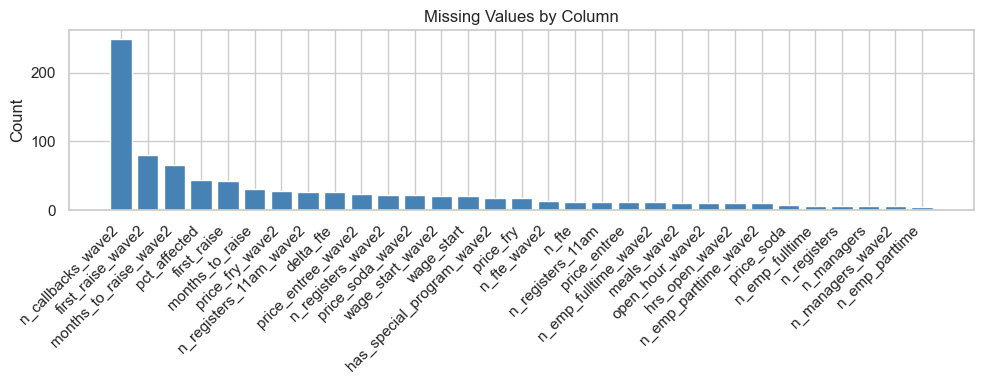

In [21]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
null_pct    = (null_counts / len(df) * 100).round(1)

missing_summary = pd.DataFrame({'missing': null_counts, 'pct_missing': null_pct})
print(f"Total rows: {len(df)}\n")
print(missing_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(null_counts.index, null_counts.values, color='steelblue')
ax.set_title('Missing Values by Column')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Sample Composition

How many stores per state, per chain, and second-interview status?

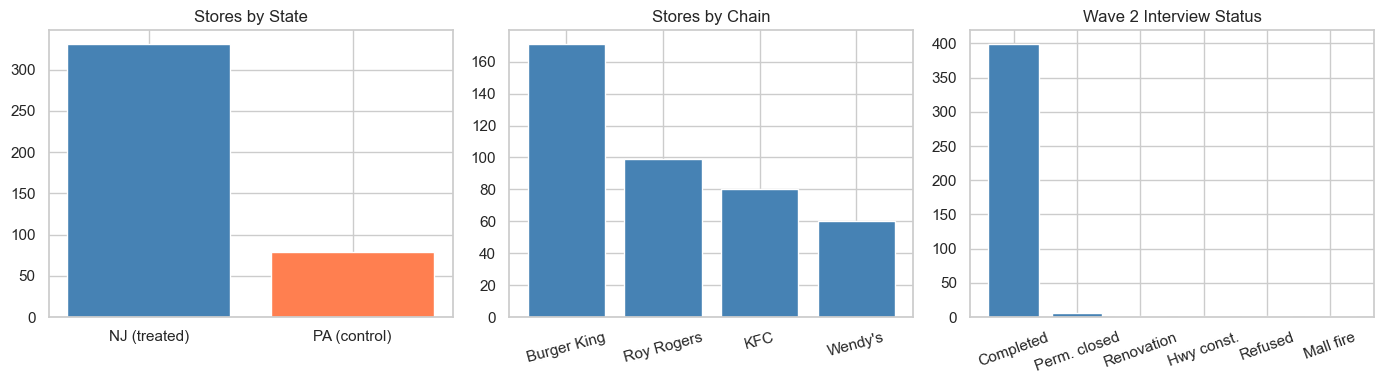

In [22]:
status_map = {
    0: 'Refused',
    1: 'Completed',
    2: 'Renovation',
    3: 'Perm. closed',
    4: 'Hwy const.',
    5: 'Mall fire',
}
df['status_wave2_label'] = df['status_wave2'].map(status_map)

state_counts  = df['state_label'].value_counts()
chain_counts  = df['chain_label'].value_counts()
status_counts = df['status_wave2_label'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(state_counts.index, state_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Stores by State')
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(chain_counts.index, chain_counts.values, color='steelblue')
axes[1].set_title('Stores by Chain')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(status_counts.index, status_counts.values, color='steelblue')
axes[2].set_title('Wave 2 Interview Status')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Wage Distributions — Before & After

NJ stores at or below $4.25 were *affected* by the policy; PA stores and high-wage NJ stores were not. We expect a bunching of NJ Wave 1 wages at $4.25 (the old minimum) and Wave 2 wages bunching at $5.05 (the new minimum).

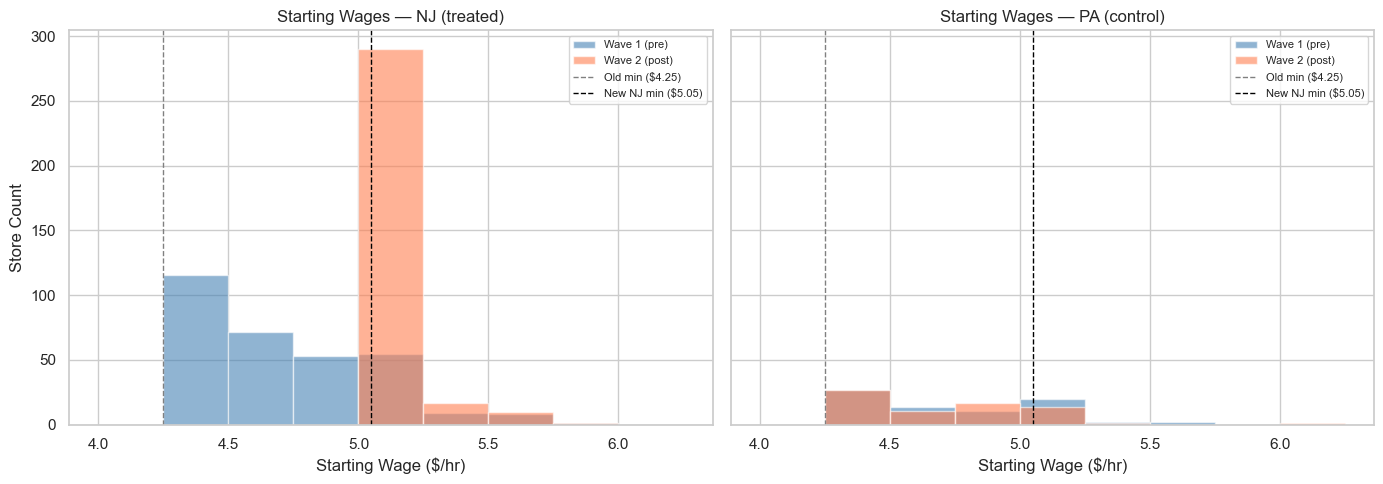

In [23]:
nj = df[df['is_nj'] == 1]
pa = df[df['is_nj'] == 0]

wage_bins = np.arange(4.00, 6.26, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# NJ (treated)
axes[0].hist(nj['wage_start'].dropna(),       bins=wage_bins, alpha=0.6, label='Wave 1 (pre)',  color='steelblue')
axes[0].hist(nj['wage_start_wave2'].dropna(), bins=wage_bins, alpha=0.6, label='Wave 2 (post)', color='coral')
axes[0].axvline(4.25, color='gray',  linestyle='--', linewidth=1, label='Old min ($4.25)')
axes[0].axvline(5.05, color='black', linestyle='--', linewidth=1, label='New NJ min ($5.05)')
axes[0].set_title('Starting Wages — NJ (treated)')
axes[0].set_xlabel('Starting Wage ($/hr)')
axes[0].set_ylabel('Store Count')
axes[0].legend(fontsize=8)

# PA (control)
axes[1].hist(pa['wage_start'].dropna(),       bins=wage_bins, alpha=0.6, label='Wave 1 (pre)',  color='steelblue')
axes[1].hist(pa['wage_start_wave2'].dropna(), bins=wage_bins, alpha=0.6, label='Wave 2 (post)', color='coral')
axes[1].axvline(4.25, color='gray',  linestyle='--', linewidth=1, label='Old min ($4.25)')
axes[1].axvline(5.05, color='black', linestyle='--', linewidth=1, label='New NJ min ($5.05)')
axes[1].set_title('Starting Wages — PA (control)')
axes[1].set_xlabel('Starting Wage ($/hr)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Employment Distributions — Before & After

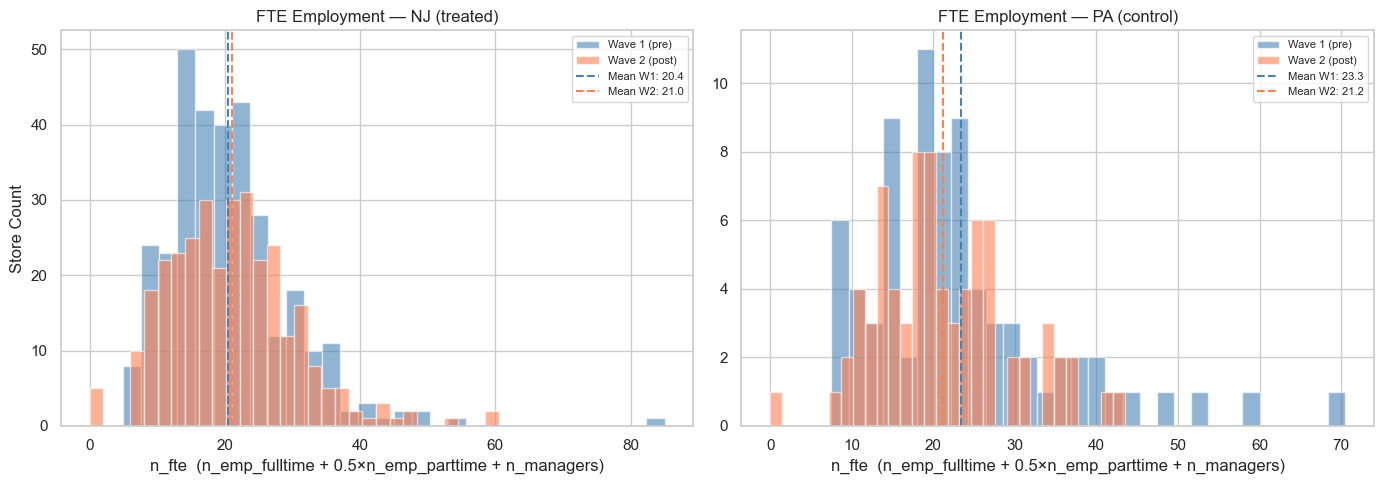

In [24]:
nj = df[df['is_nj'] == 1]
pa = df[df['is_nj'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NJ employment
axes[0].hist(nj['n_fte'].dropna(),       bins=30, alpha=0.6, label='Wave 1 (pre)',  color='steelblue')
axes[0].hist(nj['n_fte_wave2'].dropna(), bins=30, alpha=0.6, label='Wave 2 (post)', color='coral')
axes[0].axvline(nj['n_fte'].mean(),       color='steelblue', linestyle='--', linewidth=1.5,
                label=f"Mean W1: {nj['n_fte'].mean():.1f}")
axes[0].axvline(nj['n_fte_wave2'].mean(), color='coral',     linestyle='--', linewidth=1.5,
                label=f"Mean W2: {nj['n_fte_wave2'].mean():.1f}")
axes[0].set_title('FTE Employment — NJ (treated)')
axes[0].set_xlabel('n_fte  (n_emp_fulltime + 0.5×n_emp_parttime + n_managers)')
axes[0].set_ylabel('Store Count')
axes[0].legend(fontsize=8)

# PA employment
axes[1].hist(pa['n_fte'].dropna(),       bins=30, alpha=0.6, label='Wave 1 (pre)',  color='steelblue')
axes[1].hist(pa['n_fte_wave2'].dropna(), bins=30, alpha=0.6, label='Wave 2 (post)', color='coral')
axes[1].axvline(pa['n_fte'].mean(),       color='steelblue', linestyle='--', linewidth=1.5,
                label=f"Mean W1: {pa['n_fte'].mean():.1f}")
axes[1].axvline(pa['n_fte_wave2'].mean(), color='coral',     linestyle='--', linewidth=1.5,
                label=f"Mean W2: {pa['n_fte_wave2'].mean():.1f}")
axes[1].set_title('FTE Employment — PA (control)')
axes[1].set_xlabel('n_fte  (n_emp_fulltime + 0.5×n_emp_parttime + n_managers)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. DiD Preview — The 2×2 Table

This is the core of the Card & Krueger argument. The DiD estimator is:

`DiD = (NJ_after − NJ_before) − (PA_after − PA_before)`

A positive DiD would mean NJ employment *rose* relative to PA after the minimum wage increase.

2×2 DiD Table — Mean FTE Employment

                       Wave 1 (Before)   Wave 2 (After)    Change
NJ (treated)                     20.44            21.03     +0.59
PA (control)                     23.33            21.17     -2.17

DiD estimate (NJ change − PA change): +2.75 FTE employees


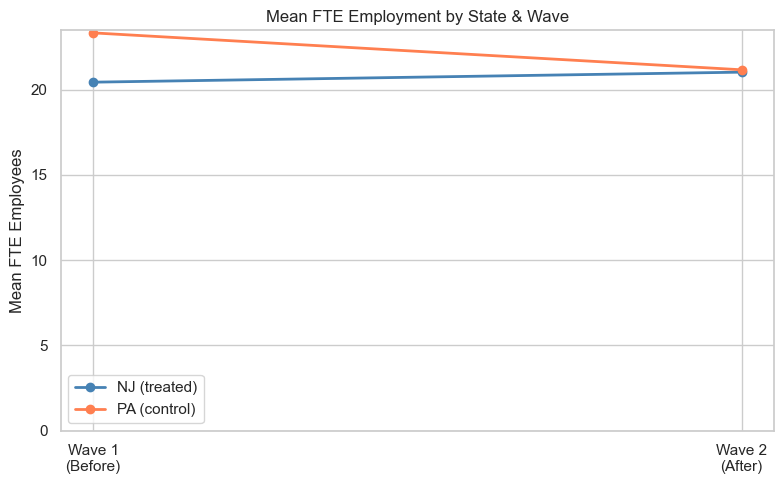

In [25]:
nj_before = df.loc[df['is_nj'] == 1, 'n_fte'].mean()
nj_after  = df.loc[df['is_nj'] == 1, 'n_fte_wave2'].mean()
pa_before = df.loc[df['is_nj'] == 0, 'n_fte'].mean()
pa_after  = df.loc[df['is_nj'] == 0, 'n_fte_wave2'].mean()

nj_change    = nj_after  - nj_before
pa_change    = pa_after  - pa_before
did_estimate = nj_change - pa_change

print("2×2 DiD Table — Mean FTE Employment\n")
print(f"{'':20s}  {'Wave 1 (Before)':>16}  {'Wave 2 (After)':>15}  {'Change':>8}")
print(f"{'NJ (treated)':20s}  {nj_before:>16.2f}  {nj_after:>15.2f}  {nj_change:>+8.2f}")
print(f"{'PA (control)':20s}  {pa_before:>16.2f}  {pa_after:>15.2f}  {pa_change:>+8.2f}")
print(f"\nDiD estimate (NJ change − PA change): {did_estimate:+.2f} FTE employees")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(['Wave 1\n(Before)', 'Wave 2\n(After)'], [nj_before, nj_after],
        marker='o', linewidth=2, label='NJ (treated)', color='steelblue')
ax.plot(['Wave 1\n(Before)', 'Wave 2\n(After)'], [pa_before, pa_after],
        marker='o', linewidth=2, label='PA (control)', color='coral')

ax.set_title('Mean FTE Employment by State & Wave')
ax.set_ylabel('Mean FTE Employees')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()